# **Group 8 CW 2 -  Task A**

In [1]:
import sys
!{sys.executable} -m pip install yfinance yahoofinancials yellowbrick scikit-learn pandas numpy seaborn requests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for yahoofinancials: filename=yahoofinancials-1.20-py3-none-any.whl size=38618 sha256=c97337569ae36ed054c68e59a475eabc1193036736523a4cd88ab53f5ce6a8ce
  Stored in directory: /root/.cache/pip/wheels/b0/e1/ca/e683b02e57db550881c8ebb89ba3eccb7a5c0ebfad7f03acea
Successfully built yahoofinancials


In [ ]:
# !pip install yahoofinancials
# !pip install yfinance

In [2]:
# Import relevant libraries
import yfinance as yf
from yahoofinancials import YahooFinancials
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import requests

In [3]:
# First we create a function to extract our S&P tickers from Wikipedia


def get_sp500_tickers():
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

    session = requests.Session()
    session.headers.update({
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    })

    response = session.get(url)
    response.raise_for_status()

    payload = pd.read_html(response.text)

    sp500_tickers = payload[0]["Symbol"].tolist()
    company_names = payload[0][['Symbol', 'Security']]
    company_names.columns = ['ticker', 'company']

    return sp500_tickers, company_names

In [4]:
"""

Here we create a function to extract the S&P data from yfinance
We supply the following arguments to the function:
Tickers which will be gotten from the get_sp500_tickers function
Index which is defaulted to yfinance '^GSPC' benchmark
Start and end date defaulted to values as specified in the course work
Interval defaulted to daily since our analysis focusses on daily performance

"""

def get_sp500_data(tickers, index='^GSPC', start="2022-01-01", end="2025-01-01", interval="1d"):
  all_tickers = tickers + [index]

  # We extract only the closing stock price
  data = yf.download(all_tickers, start=start, end=end)["Close"]
  return data


In [5]:
"""
Here we create a function to get some other information from YahooFinancials library
We get information like sector, sector outlook, valuation status, innovativeness, and sustainability
"""

def get_additional_sp500_info(tickers, max_workers=8, country="US"):
    yahoo_financials = YahooFinancials(
        tickers,
        concurrent=True,
        max_workers=max_workers,
        country=country
    ).get_insights()

    results = []

    for ticker, info in yahoo_financials.items():
        instrument = info.get('instrumentInfo', {})
        technicals = instrument.get('technicalEvents', {})
        valuation = instrument.get('valuation', {})
        company = info.get('companySnapshot', {}).get('company', {})

        results.append({
            'ticker': ticker,
            'sector': technicals.get('sector', 'Unknown'),
            'sector_outlook': technicals.get('shortTermOutlook', {}).get('sectorDirection', 'Unknown'),
            'valuation_status': valuation.get('description', 'Unknown'),
            'innovativeness': company.get('innovativeness', 0.0),
            'sustainability': company.get('sustainability', 0.0)
        })

    df = pd.DataFrame(results)

    return df

In [6]:
# Now we create a function to calculate the following metrics:
# 1. Daily Return (mean)
# 2. Beta
# 3. Annual Volatility



def calculate_ratios(returns, benchmark_returns):
    # 1. Daily Return (mean)
    # The daily returns is already calculated in using ret = yf_data[ticker].pct_change().dropna()
    # We just need to find the average now
    daily_return = returns.mean()

    # 2. Beta
    correlation = returns.corr(benchmark_returns)
    beta = correlation * (returns.std() / benchmark_returns.std())

    # 3. Annual Volatility
    annual_volatility = returns.std() * (252 ** 0.5)

    return daily_return, beta, annual_volatility

# **Exploratory Analysis**

## **Please see function that combines all the relevant steps at the end of this Notebook**

In [7]:
# We extract our tickers using our get_sp500_tickers function

tickers, company_names = get_sp500_tickers()

/tmp/ipykernel_13788/3120310631.py:15: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  payload = pd.read_html(response.text)


In [8]:
# Inspecting tickers
print(tickers)

['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'AON', 'APA', 'APO', 'AAPL', 'AMAT', 'APP', 'APTV', 'ACGL', 'ADM', 'ARES', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP', 'AZO', 'AVB', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BRK.B', 'BBY', 'TECH', 'BIIB', 'BLK', 'BX', 'XYZ', 'BK', 'BA', 'BKNG', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF.B', 'BLDR', 'BG', 'BXP', 'CHRW', 'CDNS', 'CPT', 'CPB', 'COF', 'CAH', 'CCL', 'CARR', 'CVNA', 'CASY', 'CAT', 'CBOE', 'CBRE', 'CDW', 'COR', 'CNC', 'CNP', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CIEN', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'COHR', 'COIN', 'CL', 'CMCSA', 'FIX', 'CAG', 'COP', 'ED', 'STZ', 'CEG', 'COO', 'CPRT', 'GLW', 'CPAY', 'CTVA', 'CSGP', 'COST', 'CTRA', 'CRH', 'CRWD', 'CCI

In [9]:
# Inpecting company names
company_names.head(10)

,ticker,company
0,MMM,3M
1,AOS,A. O. Smith
2,ABT,Abbott Laboratories
3,ABBV,AbbVie
4,ACN,Accenture
5,ADBE,Adobe Inc.
6,AMD,Advanced Micro Devices
7,AES,AES Corporation
8,AFL,Aflac
9,A,Agilent Technologies


In [10]:
# Extracting and inspecting the yfinace S&P data

yf_data = get_sp500_data(tickers)
yf_data.head()

/tmp/ipykernel_13788/125536664.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(all_tickers, start=start, end=end)["Close"]
[*********************100%***********************]  504 of 504 completed
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01)')
ERROR:yfinance:['Q', 'SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702148,178.103683,115.847183,172.679993,128.346024,42.362530,380.485291,564.369995,164.526459,60.037273,...,85.125771,59.164791,54.760239,110.957497,164.029999,125.887215,120.797722,583.900024,224.021225,4796.560059
2022-01-04,146.573685,175.843246,115.624809,170.800003,125.327522,42.914051,377.766266,554.000000,163.040482,61.151516,...,84.854195,59.539253,56.819996,112.134552,156.330002,126.560326,122.023193,587.599976,215.492279,4793.540039
2022-01-05,144.062729,171.165863,116.232170,162.250000,124.764427,42.410072,371.113586,514.429993,160.523590,60.674000,...,81.711815,60.122711,57.526684,110.606262,143.490005,124.955971,121.620949,558.179993,207.298355,4700.580078
2022-01-06,144.566833,168.308517,115.684669,159.750000,124.745964,42.657307,353.192291,514.119995,161.034393,61.213421,...,82.090080,59.652439,58.879745,110.454391,144.660004,126.246819,120.610626,555.159973,208.121552,4696.049805
2022-01-07,140.718079,168.474854,115.385277,166.050003,125.133629,42.856995,346.418152,510.700012,156.808640,61.735195,...,82.002785,60.174953,59.362358,109.571587,141.539993,124.799202,119.880959,530.859985,202.062317,4677.029785


In [11]:
# We see our data is complete

yf_data.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-24,134.457245,256.797211,172.530685,134.990005,112.058296,92.669998,353.541504,447.940002,213.882034,48.364082,...,87.733513,65.030975,101.953659,116.360298,91.080002,131.828506,105.724747,395.440002,161.848892,6040.040039
2024-12-26,134.190521,257.612701,171.763855,135.320007,112.556282,92.930000,352.368317,450.160004,213.852631,48.344978,...,88.257256,65.002388,102.039902,116.675446,91.480003,132.805008,105.675484,396.850006,162.654724,6037.589844
2024-12-27,133.904007,254.201385,170.623245,133.384995,112.282867,92.339996,348.213348,446.480011,212.803284,48.316322,...,87.634689,64.964241,102.030327,115.749687,88.970001,132.053085,105.301071,389.070007,161.750641,5970.839844
2024-12-30,132.797516,250.829803,168.888367,131.809998,110.144440,91.889999,344.605927,445.799988,208.458771,47.829144,...,84.818275,64.439873,101.340416,114.518623,87.480003,130.383286,104.086380,383.850006,159.431488,5906.939941
2024-12-31,132.963806,249.059448,170.326111,131.410004,110.447136,92.349998,343.921570,444.679993,208.360703,48.259007,...,85.144394,64.373138,103.074776,114.262566,84.989998,131.008255,104.313515,386.220001,160.109528,5881.629883


In [13]:
# From the above, We see some errors in some Tickers for various reasons such as been delisted or no data found in our selected date range
# We will clean exclude these Tickers from our dataset before further processing
# We see this issue in the following Tickers: BF.B.  BRK.B, Q, SNDK


# First we inspect all the tickers with missing information

missing = yf_data.isna().sum()
missing[missing > 0].sort_values(ascending=False)

,0
Ticker,
BF.B,753
BRK.B,753
SNDK,753
Q,753
GEV,560
SOLV,559
VLTO,440
KVUE,335
GEHC,240


In [14]:
# We will apply the following data cleaning logic:

# a) Drop all columns with 100% missing data
# b) Also delete columns or tickers with > 20% missing data
# c) Fill columns with <= 20% missing data


# First we drop columns with 100% missing data
yf_data = yf_data.dropna(axis=1, how="all")
yf_data.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702148,178.103683,115.847183,172.679993,128.346024,42.362530,380.485291,564.369995,164.526459,60.037273,...,85.125771,59.164791,54.760239,110.957497,164.029999,125.887215,120.797722,583.900024,224.021225,4796.560059
2022-01-04,146.573685,175.843246,115.624809,170.800003,125.327522,42.914051,377.766266,554.000000,163.040482,61.151516,...,84.854195,59.539253,56.819996,112.134552,156.330002,126.560326,122.023193,587.599976,215.492279,4793.540039
2022-01-05,144.062729,171.165863,116.232170,162.250000,124.764427,42.410072,371.113586,514.429993,160.523590,60.674000,...,81.711815,60.122711,57.526684,110.606262,143.490005,124.955971,121.620949,558.179993,207.298355,4700.580078
2022-01-06,144.566833,168.308517,115.684669,159.750000,124.745964,42.657307,353.192291,514.119995,161.034393,61.213421,...,82.090080,59.652439,58.879745,110.454391,144.660004,126.246819,120.610626,555.159973,208.121552,4696.049805
2022-01-07,140.718079,168.474854,115.385277,166.050003,125.133629,42.856995,346.418152,510.700012,156.808640,61.735195,...,82.002785,60.174953,59.362358,109.571587,141.539993,124.799202,119.880959,530.859985,202.062317,4677.029785


In [15]:
#  We see that BF.B.  BRK.B, Q, SNDK have now been dropped because they have 100% missing data

yf_data.isna().sum().sort_values(ascending=False)

,0
Ticker,
GEV,560
SOLV,559
VLTO,440
KVUE,335
GEHC,240
...,...
EL,0
EIX,0
EG,0


In [16]:
# Drop tickers missing more than 20% of data
yf_data = yf_data.dropna(axis=1, thresh=int(len(yf_data) * 0.8))

In [17]:
# We see that other Tickers with >20% misisng data have now been removed except CEG which has only 11 missing datapoints over 3 years
# We can fill this with pandas forward and backfill

yf_data.isna().sum().sort_values(ascending=False)

,0
Ticker,
CEG,11
NWSA,0
NWS,0
NVR,0
NVDA,0
...,...
EIX,0
EG,0
EFX,0


In [18]:
# Now we use a combination of foward fill and backfill to fix missing data
# Per pandas documentation:

"""DataFrame.ffill
Fill NA/NaN values by propagating the last valid observation to next valid

DataFrame.bfill
Fill NA/NaN values by using the next valid observation to fill the gap.
"""

yf_data = yf_data.ffill().bfill()

In [19]:

# After applying the data cleaning steps above, we no longer have misisng data
# We can now proceed with our analysis

yf_data.isna().sum().sort_values(ascending=False)

,0
Ticker,
^GSPC,0
A,0
AAPL,0
ABBV,0
ABNB,0
...,...
AKAM,0
AJG,0
AIZ,0


In [20]:
# Quick Exploratory analysis

yf_data.describe()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS,^GSPC
count,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,...,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000,753.000000
mean,130.064352,176.028012,144.169004,130.588958,103.725511,69.860612,300.094993,462.265882,176.495847,67.327986,...,85.793869,58.523285,95.599677,105.357610,74.065910,121.542171,115.551246,312.819176,169.499604,4605.013030
std,11.427631,29.480789,19.260841,20.996819,7.348766,20.305283,33.570745,89.899109,27.091134,10.397708,...,15.185090,5.086307,13.543467,18.058440,20.119664,9.464405,9.705027,65.892659,14.775502,661.914041
min,99.275688,123.046814,114.075989,82.489998,86.343643,39.623940,234.105789,275.200012,128.817596,47.170029,...,50.452812,44.842247,54.760239,69.693573,39.220001,98.459641,98.353477,197.990005,126.452545,3577.030029
25%,122.859207,153.404877,129.996780,115.940002,98.686073,45.861835,271.955536,379.329987,154.491425,57.716141,...,75.679214,54.627178,88.103432,91.162750,62.709999,113.946686,107.197044,268.269989,160.351318,4090.379883
50%,130.553497,171.187927,138.039398,129.699997,102.849205,70.984573,297.562958,477.700012,174.189911,67.984009,...,88.351807,58.886124,97.631462,103.293793,68.559998,122.868973,115.247932,300.459991,169.566696,4415.240234
75%,137.322235,189.590439,157.459534,146.699997,109.288414,86.826546,323.124176,530.239990,190.571106,74.998436,...,97.715828,62.256718,106.137535,122.399429,79.510002,129.813324,122.031349,340.450012,180.335083,5137.080078
max,155.217957,257.612701,195.410156,186.639999,128.346024,109.220207,380.485291,634.760010,236.697983,88.012070,...,112.340446,69.521469,119.151840,142.584885,164.029999,137.783875,141.966705,587.599976,224.021225,6090.270020


In [21]:
yf_data.shape

(753, 495)

In [22]:
yf_data.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702148,178.103683,115.847183,172.679993,128.346024,42.362530,380.485291,564.369995,164.526459,60.037273,...,85.125771,59.164791,54.760239,110.957497,164.029999,125.887215,120.797722,583.900024,224.021225,4796.560059
2022-01-04,146.573685,175.843246,115.624809,170.800003,125.327522,42.914051,377.766266,554.000000,163.040482,61.151516,...,84.854195,59.539253,56.819996,112.134552,156.330002,126.560326,122.023193,587.599976,215.492279,4793.540039
2022-01-05,144.062729,171.165863,116.232170,162.250000,124.764427,42.410072,371.113586,514.429993,160.523590,60.674000,...,81.711815,60.122711,57.526684,110.606262,143.490005,124.955971,121.620949,558.179993,207.298355,4700.580078
2022-01-06,144.566833,168.308517,115.684669,159.750000,124.745964,42.657307,353.192291,514.119995,161.034393,61.213421,...,82.090080,59.652439,58.879745,110.454391,144.660004,126.246819,120.610626,555.159973,208.121552,4696.049805
2022-01-07,140.718079,168.474854,115.385277,166.050003,125.133629,42.856995,346.418152,510.700012,156.808640,61.735195,...,82.002785,60.174953,59.362358,109.571587,141.539993,124.799202,119.880959,530.859985,202.062317,4677.029785


In [23]:
# Because we dropped some tickers as part of our data cleaning steps, we need to update our tickers to discard those dropped

index = '^GSPC'

updated_tickers = yf_data.columns.tolist()
updated_tickers.remove(index) #We also exclude out benchmark from our tickers of interest
updated_tickers

['A',
 'AAPL',
 'ABBV',
 'ABNB',
 'ABT',
 'ACGL',
 'ACN',
 'ADBE',
 'ADI',
 'ADM',
 'ADP',
 'ADSK',
 'AEE',
 'AEP',
 'AES',
 'AFL',
 'AIG',
 'AIZ',
 'AJG',
 'AKAM',
 'ALB',
 'ALGN',
 'ALL',
 'ALLE',
 'AMAT',
 'AMCR',
 'AMD',
 'AME',
 'AMGN',
 'AMP',
 'AMT',
 'AMZN',
 'ANET',
 'AON',
 'AOS',
 'APA',
 'APD',
 'APH',
 'APO',
 'APP',
 'APTV',
 'ARE',
 'ARES',
 'ATO',
 'AVB',
 'AVGO',
 'AVY',
 'AWK',
 'AXON',
 'AXP',
 'AZO',
 'BA',
 'BAC',
 'BALL',
 'BAX',
 'BBY',
 'BDX',
 'BEN',
 'BG',
 'BIIB',
 'BK',
 'BKNG',
 'BKR',
 'BLDR',
 'BLK',
 'BMY',
 'BR',
 'BRO',
 'BSX',
 'BX',
 'BXP',
 'C',
 'CAG',
 'CAH',
 'CARR',
 'CASY',
 'CAT',
 'CB',
 'CBOE',
 'CBRE',
 'CCI',
 'CCL',
 'CDNS',
 'CDW',
 'CEG',
 'CF',
 'CFG',
 'CHD',
 'CHRW',
 'CHTR',
 'CI',
 'CIEN',
 'CINF',
 'CL',
 'CLX',
 'CMCSA',
 'CME',
 'CMG',
 'CMI',
 'CMS',
 'CNC',
 'CNP',
 'COF',
 'COHR',
 'COIN',
 'COO',
 'COP',
 'COR',
 'COST',
 'CPAY',
 'CPB',
 'CPRT',
 'CPT',
 'CRH',
 'CRL',
 'CRM',
 'CRWD',
 'CSCO',
 'CSGP',
 'CSX',
 'CTAS',
 'C

In [24]:
# Finally, we use our calculate_ratios function to compute our metrics for the different stocks


results = []
index = '^GSPC'
benchmark = yf_data[index].pct_change().dropna()


for ticker in updated_tickers:

    # We calculate the daily returns as a percentage here
    ret = yf_data[ticker].pct_change().dropna()
    aligned = pd.concat([ret, benchmark], axis=1, join='inner').dropna()


    # We calculate our desired Metrics using our calculate_ratios function here
    daily_return, beta, annual_volatility = calculate_ratios(aligned[ticker], aligned[index])

    # We save our results to the empty list initialized above
    results.append({'ticker': ticker, 'daily_return': daily_return, 'beta': beta, 'annual_volatility': annual_volatility})


# We write all our results to a dataframe
data = pd.DataFrame(results).sort_values('daily_return', ascending=False)

In [25]:
# We inspect our S&P data with relevant metrics
data

,ticker,daily_return,beta,annual_volatility
401,SMCI,0.004106,1.855255,0.901957
124,CVNA,0.003219,3.294068,1.341039
463,VRT,0.002857,2.060915,0.629826
465,VST,0.002837,1.003985,0.419351
39,APP,0.002802,2.261933,0.788374
...,...,...,...,...
40,APTV,-0.000991,1.496814,0.418653
135,DG,-0.001144,0.525849,0.378654
54,BAX,-0.001171,0.581685,0.298554
311,MRNA,-0.001582,1.427285,0.603608


In [26]:
# Now we get our addiitonal data from YahooFinancials using the get_additional_sp500_info function

additional_data = get_additional_sp500_info(updated_tickers)
additional_data.head()

,ticker,sector,sector_outlook,valuation_status,innovativeness,sustainability
0,A,Unknown,Unknown,Unknown,0.9336,0.0120
1,AAPL,Unknown,Unknown,Unknown,0.9981,0.1652
2,ABBV,Unknown,Unknown,Unknown,0.9451,0.2684
3,ABNB,Unknown,Unknown,Unknown,0.8382,0.2829
4,ABT,Unknown,Unknown,Unknown,0.9630,0.1081


In [27]:
data

,ticker,daily_return,beta,annual_volatility
401,SMCI,0.004106,1.855255,0.901957
124,CVNA,0.003219,3.294068,1.341039
463,VRT,0.002857,2.060915,0.629826
465,VST,0.002837,1.003985,0.419351
39,APP,0.002802,2.261933,0.788374
...,...,...,...,...
40,APTV,-0.000991,1.496814,0.418653
135,DG,-0.001144,0.525849,0.378654
54,BAX,-0.001171,0.581685,0.298554
311,MRNA,-0.001582,1.427285,0.603608


In [28]:
# Now we enrich our data with company names and additional info from YahooFinancials
combined_data = pd.merge(data, company_names, on='ticker', how='inner')
combined_data = pd.merge(combined_data, additional_data, on='ticker', how='left')
combined_data.head()

,ticker,daily_return,beta,annual_volatility,company,sector,sector_outlook,valuation_status,innovativeness,sustainability
0,SMCI,0.004106,1.855255,0.901957,Supermicro,Unknown,Unknown,Unknown,0.5731,0.4030
1,CVNA,0.003219,3.294068,1.341039,Carvana,Unknown,Unknown,Unknown,0.8505,0.1160
2,VRT,0.002857,2.060915,0.629826,Vertiv,Unknown,Unknown,Unknown,0.0000,0.5691
3,VST,0.002837,1.003985,0.419351,Vistra Corp.,Unknown,Unknown,Unknown,0.2647,0.3611
4,APP,0.002802,2.261933,0.788374,AppLovin,Unknown,Unknown,Unknown,0.0000,0.2786


In [29]:
# Here we package all the steps above into a single function

def yf_data_processing(index='^GSPC'):

  # Get stock data tickers from wikipedia
  tickers, company_names = get_sp500_tickers()

  # Get stock data from yfinance using tickers above
  yf_data = get_sp500_data(tickers)

  # Drop all tickers with 100% misisng data
  yf_data = yf_data.dropna(axis=1, how="all")

  # Drop tickers missing more than 20% of data
  yf_data = yf_data.dropna(axis=1, thresh=int(len(yf_data) * 0.8))

  # Now we use a combination of foward fill and backfill to fix missing data
  yf_data = yf_data.ffill().bfill()

  # After processing our data above, we need to update our tickers since some of them have been removed from the dataset
  #This way, we only process stocks with enough and already processed data

  updated_tickers = yf_data.columns.tolist()
  updated_tickers.remove(index) #we also remove our benchmark


  # Compute benchmark daily returns
  benchmark = yf_data[index].pct_change().dropna()

  results = []

  for ticker in updated_tickers:
      ret = yf_data[ticker].pct_change().dropna()
      aligned = pd.concat([ret, benchmark], axis=1, join='inner').dropna()

      daily_return, beta, annual_volatility = calculate_ratios(aligned[ticker], aligned[index])
      results.append({'ticker': ticker, 'daily_return': daily_return, 'beta': beta, 'annual_volatility': annual_volatility})

  data = pd.DataFrame(results).sort_values('daily_return', ascending=False)

  # Now we get our addiitonal data from YahooFinancials using the get_additional_sp500_info function
  additional_data = get_additional_sp500_info(updated_tickers)

  # Now we enrich our data with company names and additional info from YahooFinancials
  combined_data = pd.merge(data, company_names, on='ticker', how='inner')
  combined_data = pd.merge(combined_data, additional_data, on='ticker', how='left')


  return combined_data

In [30]:
df = yf_data_processing()
df.head()

/tmp/ipykernel_13788/3120310631.py:15: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  payload = pd.read_html(response.text)
/tmp/ipykernel_13788/125536664.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(all_tickers, start=start, end=end)["Close"]
[*********************100%***********************]  504 of 504 completed
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01)')
ERROR:yfinance:['Q', 'SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')


,ticker,daily_return,beta,annual_volatility,company,sector,sector_outlook,valuation_status,innovativeness,sustainability
0,SMCI,0.004106,1.855255,0.901957,Supermicro,Technology,Unknown,Undervalued,0.5731,0.4030
1,CVNA,0.003219,3.294068,1.341039,Carvana,Unknown,Unknown,Unknown,0.8505,0.1160
2,VRT,0.002857,2.060915,0.629826,Vertiv,Unknown,Unknown,Unknown,0.0000,0.5691
3,VST,0.002837,1.003986,0.419351,Vistra Corp.,Unknown,Unknown,Unknown,0.2647,0.3611
4,APP,0.002802,2.261933,0.788374,AppLovin,Unknown,Unknown,Unknown,0.0000,0.2786


In [31]:
# Now we save our df as csv
df.to_csv("/content/sp500_data.csv")

In [32]:
df.shape

(494, 10)

In [33]:
"""
Followwing thr analysis above we have 495 S&P 500 stocks with 10 attributes
such as ticker, daily return, beta, annual volatility, sector, sector outlook, valuation status, innovativeness, and sustainability
"""

'\nFollowwing thr analysis above we have 495 S&P 500 stocks with 10 attributes\nsuch as ticker, daily return, beta, annual volatility, sector, sector outlook, valuation status, innovativeness, and sustainability\n'

# **Illustration and Segmentation using Daily Return, Beta & Annual Volatility**

In [ ]:
"""
Definitions:

Daily Return:
This measures the average percentage gain or loss of a stock in a single day. It is a direct metric that
tells whether a stock is porfitable or not

Beta:
This measures how a stock moves relative the the market or index (S&P 500). It is an indication a stock's
stability and risk reletive to the market.

Annual Volatility:
This measures the variability or risk ion terms of price swings of a stock. It is an indication fo risk with higher
volatility scores indicating higher risk.
"""


In [34]:
# Lets subset our data for further analysis

sp_500_performance = df[['ticker', 'daily_return', 'beta', 'annual_volatility']]
sp_500_performance.head()

,ticker,daily_return,beta,annual_volatility
0,SMCI,0.004106,1.855255,0.901957
1,CVNA,0.003219,3.294068,1.341039
2,VRT,0.002857,2.060915,0.629826
3,VST,0.002837,1.003986,0.419351
4,APP,0.002802,2.261933,0.788374


/tmp/ipykernel_13788/2100088170.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  plt.subplot(3, 1, 1); sns.distplot(sp_500_performance['daily_return'])
/tmp/ipykernel_13788/2100088170.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  plt.subplot(3, 1, 2); sns.distplot(sp_500_performance['beta'])
/tmp/ipykernel_1378

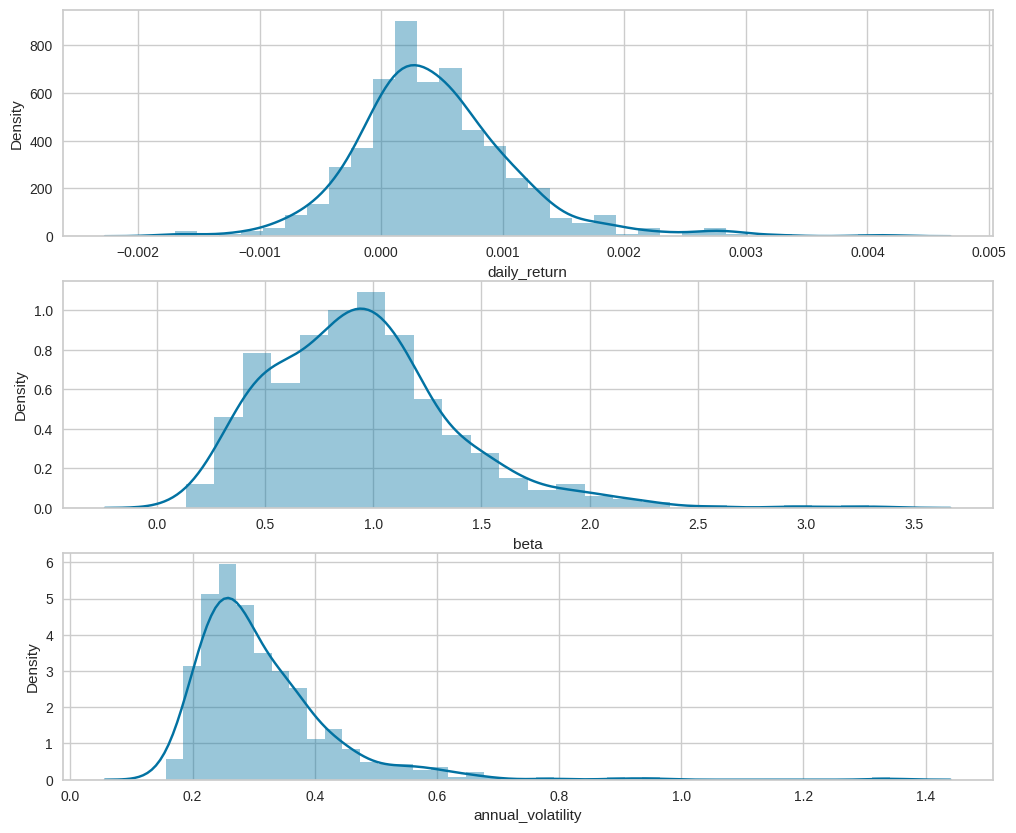

In [35]:
# Plot our distributions


plt.figure(figsize=(12,10))

# Plot distribution of daily_return
plt.subplot(3, 1, 1); sns.distplot(sp_500_performance['daily_return'])

# Plot distribution of beta
plt.subplot(3, 1, 2); sns.distplot(sp_500_performance['beta'])

# Plot distribution of annual_volatility
plt.subplot(3, 1, 3); sns.distplot(sp_500_performance['annual_volatility'])

# Show the plot
plt.show()

In [36]:
# We see daily_return more or less follows a normal distribution
# However beta and annual volatility are skewed

# We will fix the skewness in all our variables using Yeo Johnson approach because it is similar to the
# boxcox approach but can handle zero and negative valiues

# We will also scale / standardize our data before clustering with daily return, beta and annual volatility

In [37]:
# Fixing skewness using YeoJohnson approach

sp_500_performance_fix = pd.DataFrame()

sp_500_performance_fix["daily_return"] = stats.yeojohnson(sp_500_performance["daily_return"])[0]
sp_500_performance_fix["beta"] = stats.yeojohnson(sp_500_performance["beta"])[0]
sp_500_performance_fix["annual_volatility"] = stats.yeojohnson(sp_500_performance["annual_volatility"])[0]
sp_500_performance_fix.tail()

,daily_return,beta,annual_volatility
489,-0.001140,0.762530,0.139662
490,-0.001345,0.387866,0.136309
491,-0.001382,0.417849,0.126954
492,-0.001983,0.743034,0.148738
493,-0.002161,0.688297,0.139934


/tmp/ipykernel_13788/1542015640.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  plt.subplot(3, 1, 1); sns.distplot(sp_500_performance_fix['daily_return'])
/tmp/ipykernel_13788/1542015640.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  plt.subplot(3, 1, 2); sns.distplot(sp_500_performance_fix['beta'])
/tmp/ipykern

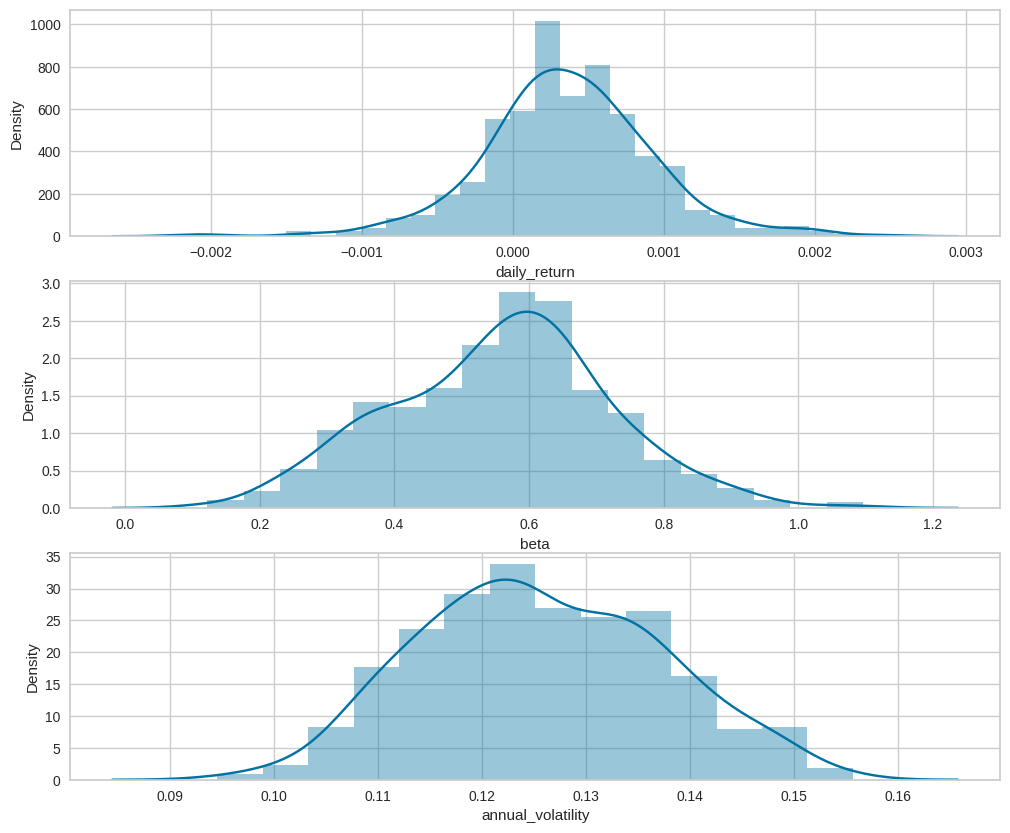

In [38]:
# Let plot our distributions again after fixing skewness

plt.figure(figsize=(12,10))

# Plot distribution of daily_return
plt.subplot(3, 1, 1); sns.distplot(sp_500_performance_fix['daily_return'])

# Plot distribution of beta
plt.subplot(3, 1, 2); sns.distplot(sp_500_performance_fix['beta'])

# Plot distribution of annual_volatility
plt.subplot(3, 1, 3); sns.distplot(sp_500_performance_fix['annual_volatility'])

# Show the plot
plt.show()

In [ ]:
# All our distributions now follow a normal distribution pattern

In [39]:
# Let us scale / standardize our data


# Initialize the Object
scaler = StandardScaler()

# Fit and Transform The Data
scaler.fit(sp_500_performance_fix)
sp500_normalized = scaler.transform(sp_500_performance_fix)


# Assert that it has mean 0 and variance 1
print(sp500_normalized.mean(axis = 0).round(2)) # [0. -0. 0.]
print(sp500_normalized.std(axis = 0).round(2)) # [1. 1. 1.]

[-0. -0. -0.]
[1. 1. 1.]


In [40]:
# Inspecting our sp500_normalized array
sp500_normalized

array([[ 3.7235342 ,  1.81826498,  2.41732436],
       [ 3.14704554,  3.32303756,  2.57921814],
       [ 2.86746013,  2.09292082,  2.04634238],
       ...,
       [-3.109077  , -0.85996419,  0.10923214],
       [-4.17845851,  1.14557925,  1.98173244],
       [-4.49561108,  0.80799506,  1.22495846]])

**Segmentation with Agglomerative Clustering**

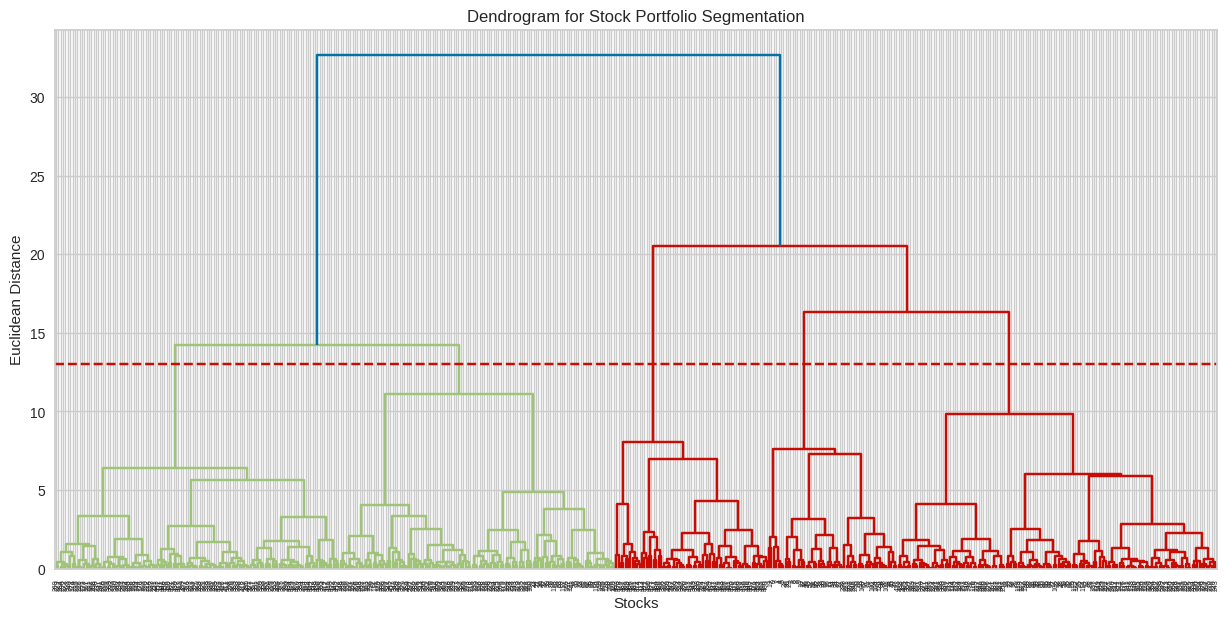

In [55]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# From the metrics/dimensions: Daily Return, Beta Value, and Annual Volatility we will plot the dendogram
# which shows the hierarchical clustering
plt.figure(figsize=(15, 7))
plt.title("Dendrogram for Stock Portfolio Segmentation")
plt.xlabel("Stocks")
plt.ylabel("Euclidean Distance")

# 'Ward' linkage technique was applied which minimises the variance within clusters
linkage_matrix = sch.linkage(sp500_normalized, method='ward')
dendrogram = sch.dendrogram(linkage_matrix)

# A visualiser for where to 'cut' the tree for N clusters (y =15 was tested first the results were sreenshoted
# the slice was moved down to y=13 to cut across the green branches as well to increase the granularity since a N number of 3 is too thin

plt.axhline(y=13, color='r', linestyle='--')
plt.show()

In [44]:
#from the dendogram we found 4 to be the optimal N-number of clusters so we can proceed with clustering
from sklearn.cluster import AgglomerativeClustering
#Euclidean distancing used due to low dimensionality of the data since we are only analysing 3 metrics
agg_model = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
agg_labels = agg_model.fit_predict(sp500_normalized)
df['agg_cluster'] = agg_labels
#used the prefix 'agg' to avoid overwriting the model used for KMeans in the next section


In [50]:
#verification
agg_cluster_table = df['agg_cluster'].value_counts().sort_index().reset_index()
agg_cluster_table.columns = ['Cluster Number', 'Number of Stocks']
print("Summary of Portfolio Segments:")
display(agg_cluster_table)

Summary of Portfolio Segments:


,Cluster Number,Number of Stocks
0,0,238
1,1,136
2,2,65
3,3,55


In [51]:
# Stocks grouped by clusters and mean values for the metrics
agg_cluster_averages = df.groupby('agg_cluster')[['daily_return', 'beta', 'annual_volatility']].mean()
agg_cluster_averages.columns = ['Avg Daily Return', 'Avg Beta (Risk)', 'Avg Volatility']
print("Table: Average Metrics per Agglomerative Cluster")
display(agg_cluster_averages)

Table: Average Metrics per Agglomerative Cluster


,Avg Daily Return,Avg Beta (Risk),Avg Volatility
agg_cluster,,,
0,0.000334,0.660620,0.239319
1,0.000611,1.085527,0.333368
2,-0.000387,1.084850,0.381349
3,0.001477,1.661855,0.516052


In [56]:
"""
Average daily return of all the stocks seem to be very similar theres little to no movement at all on a daily basis ranging from -0.3 - +1.5% growth
Agglomerative Cluster 0: For every 1% growth in S&P500 these stocks have a 0.66% growth which shows some positive influence to S&P500's growth. Low annual volatility 0.24
Agglomerative Cluster 1: These stocks move directly in line with the S%P500 indicated by a 1.08 beta value. they do hold a relatively low annual volatility of 0.33
Agglomerative Cluster 2: These stocks have a similar beta value to cluster 1 stocks and move in line with S&P500 its advisable
to not include both Cluster 1 and cluster 2 stocks in the same portfolio for diversification
Agglomerative Cluster 3: These stocks have the highest average daily return of +1.5%  but are more volatile due to a beta value of 1.67 meaning they are highly volatile to any movements of the S&P 500"""


"\nAverage daily return of all the stocks seem to be very similar theres little to no movement at all on a daily basis ranging from -0.3 - +1.5% growth\nAgglomerative Cluster 0: For every 1% growth in S&P500 these stocks have a 0.66% growth which shows some positive influence to S&P500's growth. Low annual volatility 0.24\nAgglomerative Cluster 1: These stocks move directly in line with the S%P500 indicated by a 1.08 beta value. they do hold a relatively low annual volatility of 0.33\nAgglomerative Cluster 2: These stocks have a similar beta value to cluster 1 stocks and move in line with S&P500 its advisable \nto not include both Cluster 1 and cluster 2 stocks in the same portfolio for diversification\nAgglomerative Cluster 3: These stocks have the highest average daily return of +1.5%  but are more volatile due to a beta value of 1.67 meaning they are highly volatile to any movements of the S&P 500"

In [73]:
#for closer analysis and identification we need the stocks listed within their clusters
import pandas as pd

pd.set_option('display.max_rows', None)
name_column = 'company'

for i in range(4):
    print(f"### FULL LIST: CLUSTER {i} ({len(df[df['agg_cluster'] == i])} Stocks) ###")
    cluster_names = df[df['agg_cluster'] == i][name_column].sort_values().tolist()

    for name in cluster_names:
        print(name)

    print("\n" + "="*50 + "\n")

### FULL LIST: CLUSTER 0 (238 Stocks) ###
A. O. Smith
AT&T
AbbVie
Abbott Laboratories
Accenture
Aflac
Agilent Technologies
Air Products
Akamai Technologies
Allegion
Alliant Energy
Allstate
Altria
Amcor
Ameren
American Electric Power
American International Group
American Tower
American Water Works
Ametek
Amgen
Aon plc
Arch Capital Group
Archer Daniels Midland
Arthur J. Gallagher & Co.
Assurant
Atmos Energy
AutoZone
Automatic Data Processing
AvalonBay Communities
Avery Dennison
BNY Mellon
Bank of America
Becton Dickinson
Boston Scientific
Bristol Myers Squibb
Broadridge Financial Solutions
Brown & Brown
Bunge Global
CDW Corporation
CME Group
CMS Energy
CSX Corporation
Camden Property Trust
Campbell's Company (The)
Cardinal Health
Casey's
Cboe Global Markets
Cencora
Centene Corporation
CenterPoint Energy
Chevron Corporation
Chubb Limited
Church & Dwight
Cigna
Cintas
Cisco
Clorox
Coca-Cola Company (The)
Cognizant
Colgate-Palmolive
Comcast
Conagra Brands
Consolidated Edison
Constellation Br

**Segmenting Using Kmeans and the elbow method**

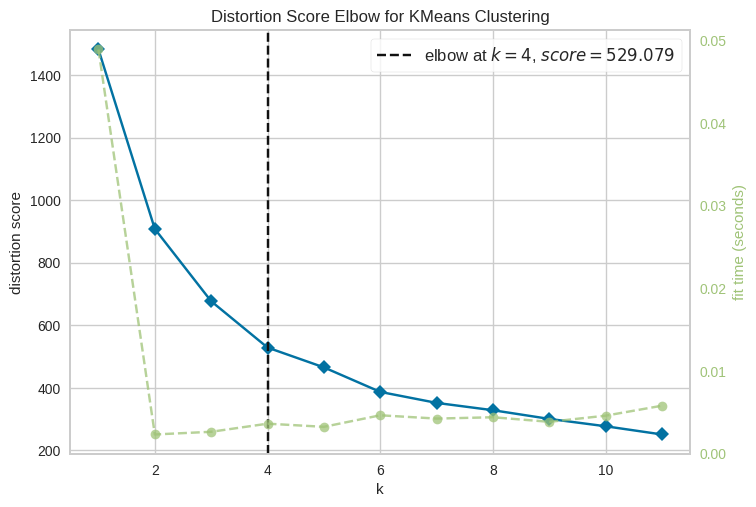

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [60]:
# Let's determine the optimal clusters using the elbow method


model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,12))
visualizer.fit(sp500_normalized)
visualizer.show()

In [61]:
# Our optimal K = 4

,cluster,count
0,0,183
1,1,147
2,2,63
3,3,101


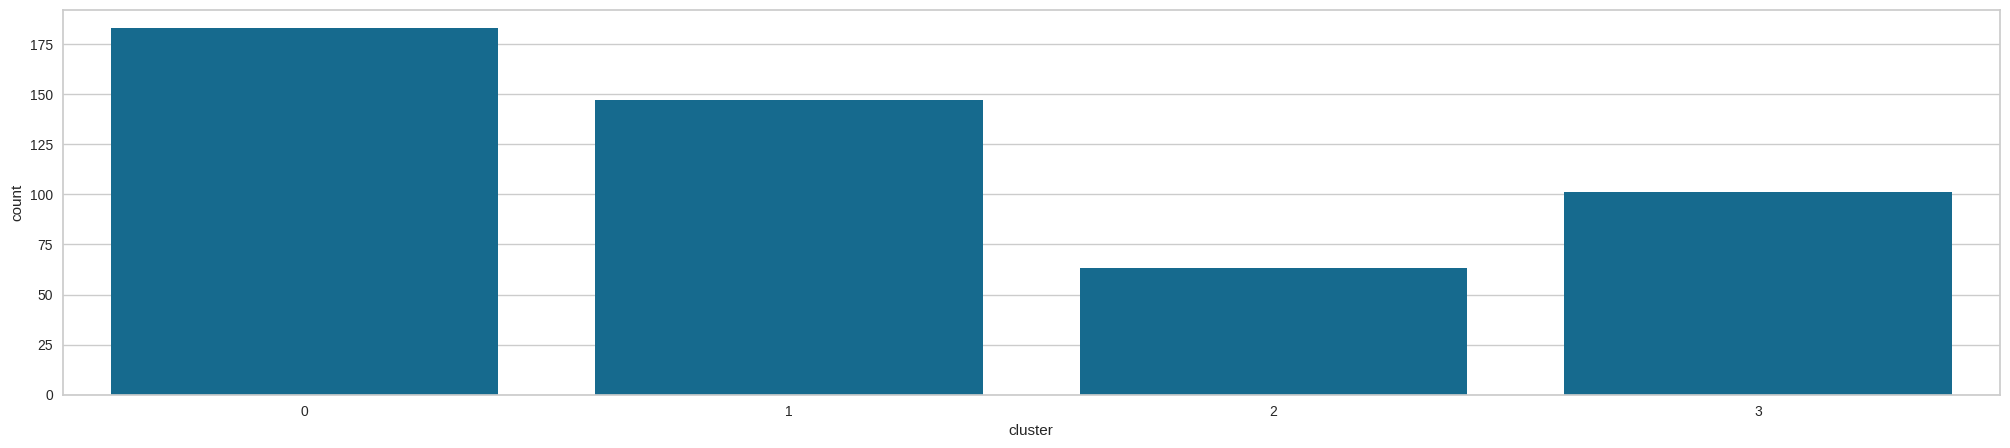

In [62]:
# Here we show the distribution of our stocks into our different clusters


model = KMeans(n_clusters=4, random_state=42)
model.fit(sp500_normalized)
model.labels_.shape
df["cluster"] = model.labels_
df.groupby('cluster').agg({
    'daily_return':'mean',
    'beta':'mean',
    'annual_volatility':['mean', 'count']}).round(2)
f, ax = plt.subplots(figsize=(25, 5))
ax = sns.countplot(x="cluster", data=df)


df.groupby('cluster').size().reset_index(name='count')

In [63]:
df.head()

,ticker,daily_return,beta,annual_volatility,company,sector,sector_outlook,valuation_status,innovativeness,sustainability,agg_cluster,cluster
0,SMCI,0.004106,1.855255,0.901957,Supermicro,Technology,Unknown,Undervalued,0.5731,0.4030,3,2
1,CVNA,0.003219,3.294068,1.341039,Carvana,Unknown,Unknown,Unknown,0.8505,0.1160,3,2
2,VRT,0.002857,2.060915,0.629826,Vertiv,Unknown,Unknown,Unknown,0.0000,0.5691,3,2
3,VST,0.002837,1.003986,0.419351,Vistra Corp.,Unknown,Unknown,Unknown,0.2647,0.3611,3,2
4,APP,0.002802,2.261933,0.788374,AppLovin,Unknown,Unknown,Unknown,0.0000,0.2786,3,2


In [64]:
# Summarizing our clusters performance across daily return, beta and annual volatitlty

df.groupby('cluster').agg({
    'daily_return':'mean',
    'beta':'mean',
    'annual_volatility':['mean', 'count']}).round(4)

daily_return    beta annual_volatility      
                mean    mean              mean count
cluster                                             
0             0.0006  0.9322            0.2893   183
1             0.0003  0.5230            0.2242   147
2             0.0014  1.5975            0.4920    63
3            -0.0002  1.1749            0.3820   101

<Axes: xlabel='Attribute', ylabel='Value'>

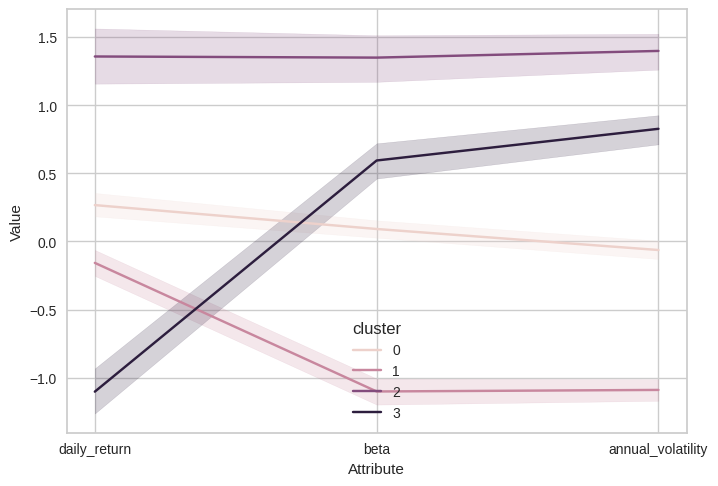

In [65]:
# Visualizing our cluster performance


# Create the dataframe
df_normalized = pd.DataFrame(sp500_normalized, columns=['daily_return', 'beta', 'annual_volatility'])
df_normalized['id'] = df.index
df_normalized['cluster'] = model.labels_


# Melt The Data
df_nor_melt = pd.melt(df_normalized.reset_index(),
                      id_vars=['id', 'cluster'],
                      value_vars=['daily_return', 'beta', 'annual_volatility'],
                      var_name='Attribute',
                      value_name='Value')
df_nor_melt.head()
# Visualize it
sns.lineplot(x = 'Attribute', y= 'Value', hue='cluster', data=df_nor_melt)

In [66]:
"""

From the above chart, we that:

Cluster 0:
These stocks have moderate daily return (just above 0) and beta and annual volatility close to zero,
These stock are quite stable and have low risk, and better suited for long term investors

Cluster 1:
These stock havenegative daily return (below 0) and beta and annual volatility close also below zero;
These are generally unprofitable stocks over the period of our analysis


Cluster 2:
These stocks have relatively higher daily returns, but also have higher beta and annual volatility, thus making
them risky and more suited for day traders

Cluster 3:
These are the worst performing stocks froom our clustering with the lowest daily return and also high
beta and annual volatility, thus making them risky and also unprofitable


"""

'\n\nFrom the above chart, we that:\n\nCluster 0:\nThese stocks have moderate daily return (just above 0) and beta and annual volatility close to zero,\nThese stock are quite stable and have low risk, and better suited for long term investors\n\nCluster 1:\nThese stock havenegative daily return (below 0) and beta and annual volatility close also below zero;\nThese are generally unprofitable stocks over the period of our analysis\n\n\nCluster 2:\nThese stocks have relatively higher daily returns, but also have higher beta and annual volatility, thus making\nthem risky and more suited for day traders\n\nCluster 3:\nThese are the worst performing stocks froom our clustering with the lowest daily return and also high\nbeta and annual volatility, thus making them risky and also unprofitable\n\n\n'

In [67]:
# Finally let's display all our stocks based on their clusters


for cluster_id in sorted(df['cluster'].unique()):
    cluster_df = df[df['cluster'] == cluster_id][
        ['cluster', 'company', 'ticker', 'daily_return', 'beta', 'annual_volatility']
    ].sort_values('daily_return', ascending=False)

    print(f"\n{'='*120}")
    print(f"Cluster {cluster_id} — {len(cluster_df)} stocks")
    print(f"{'='*120}")
    print(cluster_df.to_string(index=False))


Cluster 0 — 183 stocks
 cluster                          company ticker  daily_return     beta  annual_volatility
       0                  Targa Resources   TRGP      0.001892 0.883922           0.311018
       0                            Emcor    EME      0.001871 0.893258           0.289158
       0               TKO Group Holdings    TKO      0.001671 0.543684           0.329721
       0                      Lilly (Eli)    LLY      0.001592 0.575694           0.287856
       0                     GE Aerospace     GE      0.001562 1.027378           0.302479
       0                       NRG Energy    NRG      0.001343 0.866587           0.334246
       0                          GoDaddy   GDDY      0.001305 1.051579           0.298462
       0               Marathon Petroleum    MPC      0.001301 0.660433           0.321914
       0              Interactive Brokers   IBKR      0.001289 0.870095           0.304441
       0                    Iron Mountain    IRM      0.001276 0.9

In [70]:
print(df.columns)

Index(['ticker', 'daily_return', 'beta', 'annual_volatility', 'company',
       'sector', 'sector_outlook', 'valuation_status', 'innovativeness',
       'sustainability', 'agg_cluster', 'cluster'],
      dtype='object')
